# Libraries

In [1]:
import glob

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [44]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Data cleaning

In [5]:
no_smile = glob.glob('datasets/non_smile/*.jpg')
smile = glob.glob('datasets/smile/*.jpg')
test = glob.glob('datasets/test/*.jpg')

In [6]:
type(no_smile)

list

In [7]:
smile[0]


'datasets/smile/Pete_Sampras_0010.jpg'

In [8]:
len(no_smile), len(smile), len(test)

(603, 600, 12030)

# 2. Data Analysis & cleaning

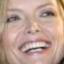

In [9]:
img = Image.open(smile[18])
img

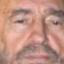

In [10]:
Image.open(no_smile[18])

In [11]:
img.size

(64, 64)

In [12]:
img = img.convert('L')

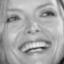

In [13]:
img

### pixel has range 0 to 255

In [14]:
# RGB to gray scale
pixel_array = np.array(img)

In [15]:
type(pixel_array)

numpy.ndarray

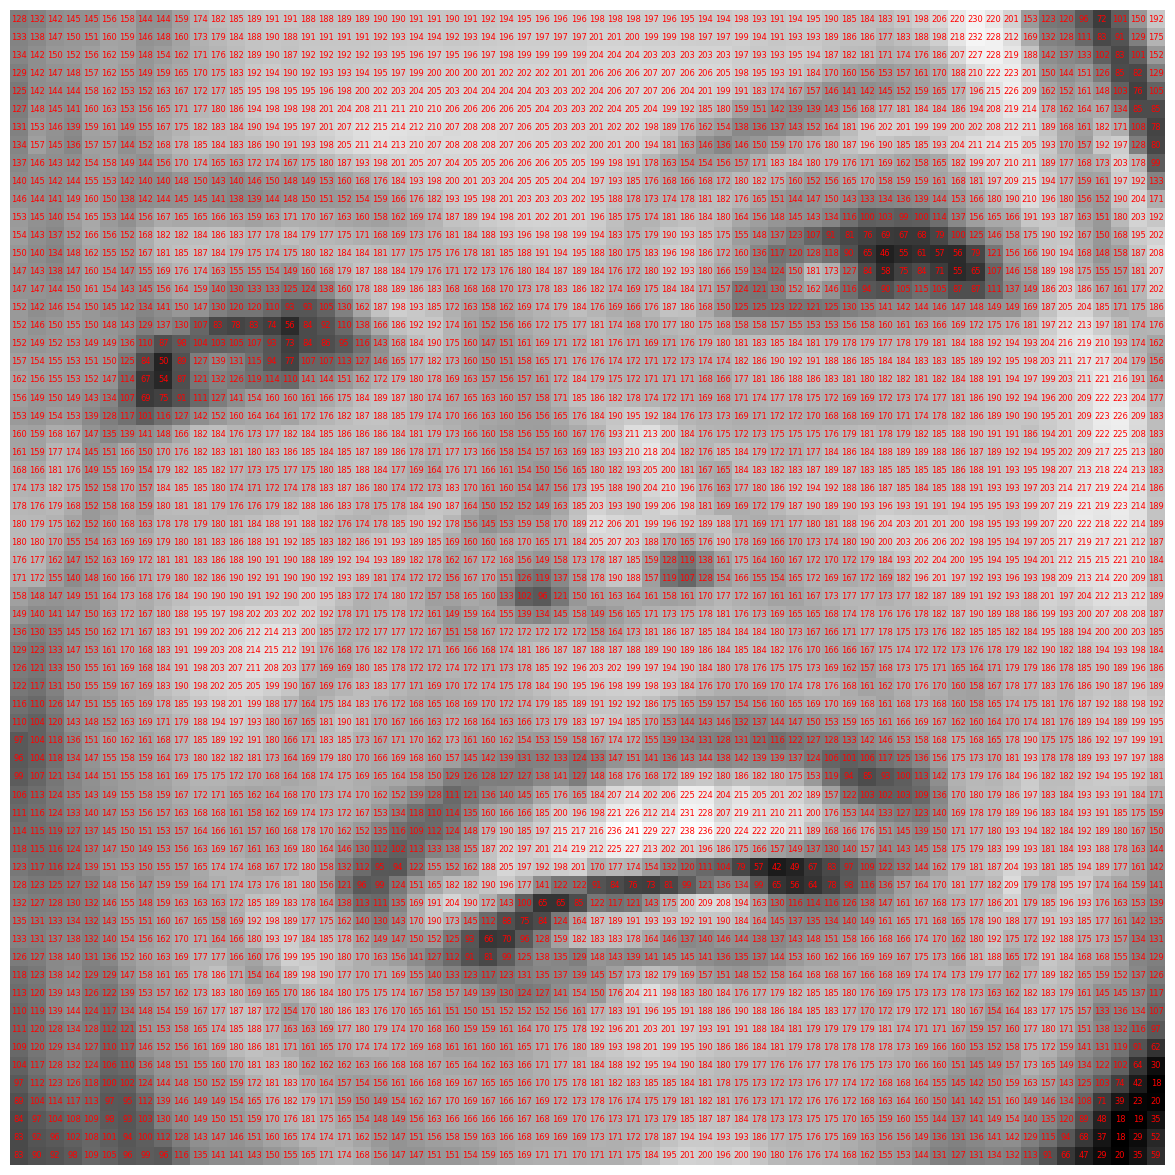

In [16]:
plt.figure(figsize=(15,15))
plt.imshow(pixel_array, cmap='gray', interpolation='nearest')

#show pixel values overlaid on images
for i in range(64):
    for j in range(64):
        plt.text(j,i,pixel_array[i,j], ha='center', va='center', fontsize=6, color='red')

plt.axis('off')
plt.show()

In [17]:
data = []
labels = []

In [18]:
# load smiling Images
for img_name in smile:
    img = Image.open(img_name).convert('L')
    img_array = np.array(img).flatten()
    data.append(img_array)
    labels.append(1) # smiling refer as 1

In [19]:
# load non-smiling Images
for img_name in no_smile:
    img = Image.open(img_name).convert('L')
    img_array = np.array(img).flatten()
    data.append(img_array)
    labels.append(0) # non-smiling refer as 0

In [20]:
len(data)

1203

In [21]:
type(data[0])

numpy.ndarray

In [22]:
type(labels[0])

int

In [23]:
X = np.array(data)
y = np.array(labels)

# model development

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=64,shuffle=True)

In [25]:
type(X_train)

numpy.ndarray

In [26]:
X_train.shape

(962, 4096)

In [27]:
X_train[0]

array([152, 147, 142, ...,  86, 102, 118], shape=(4096,), dtype=uint8)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [29]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [30]:
X_train_scaled[0]

array([ 1.06568995,  0.90558351,  0.71580409, ..., -0.0868959 ,
        0.21087075,  0.48614305], shape=(4096,))

In [31]:
model = LogisticRegression(max_iter=1000)

In [32]:
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [33]:
y_pred = model.predict(X_test_scaled)

In [34]:
y_pred

array([1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1])

In [35]:
model.predict_proba(X_test_scaled)

array([[6.12616933e-07, 9.99999387e-01],
       [9.99948059e-01, 5.19410888e-05],
       [1.66628662e-07, 9.99999833e-01],
       [8.63231127e-01, 1.36768873e-01],
       [9.99111539e-01, 8.88461281e-04],
       [9.99956745e-01, 4.32545806e-05],
       [1.34038586e-01, 8.65961414e-01],
       [6.84801562e-07, 9.99999315e-01],
       [9.52395940e-10, 9.99999999e-01],
       [9.98677286e-01, 1.32271380e-03],
       [3.60805625e-06, 9.99996392e-01],
       [9.99999962e-01, 3.76336357e-08],
       [9.99999910e-01, 8.98111411e-08],
       [9.99998209e-01, 1.79145757e-06],
       [7.00598608e-02, 9.29940139e-01],
       [4.68196530e-01, 5.31803470e-01],
       [9.99999987e-01, 1.32138103e-08],
       [6.95406046e-04, 9.99304594e-01],
       [4.11520089e-06, 9.99995885e-01],
       [9.84563716e-01, 1.54362842e-02],
       [9.86439213e-01, 1.35607868e-02],
       [9.96193547e-01, 3.80645302e-03],
       [1.86606491e-04, 9.99813394e-01],
       [3.99386404e-02, 9.60061360e-01],
       [9.999964

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print(f'model accuracy: {accuracy:.4f}')
print(f'confusion matrix: \n {confusion_matrix(y_test, y_pred)}')
print(f'classification report: \n {classification_report(y_test, y_pred)}')

model accuracy: 0.8880
confusion matrix: 
 [[107  13]
 [ 14 107]]
classification report: 
               precision    recall  f1-score   support

           0       0.88      0.89      0.89       120
           1       0.89      0.88      0.89       121

    accuracy                           0.89       241
   macro avg       0.89      0.89      0.89       241
weighted avg       0.89      0.89      0.89       241



# 4. hyperparameter tuning

In [40]:
params_grid = {
    'penalty' : ['l1', 'l2', 'elasticnet'],
    'C' : [0.01, 0.1, 1, 10, 100],
    'solver' : ['liblinear', 'lbfgs', 'sag', 'saga', 'newton-cg']
}

In [43]:
log_reg = LogisticRegression(max_iter=1000)

In [45]:
cv = StratifiedKFold()

In [46]:
# perform grid search
grid_search = GridSearchCV(log_reg, params_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)

/home/vel/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/vel/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/vel/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/vel/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/vel/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/vel/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:34

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['liblinear', 'lbfgs', 'sag', 'saga',
                                    'newton-cg']},
             scoring='accuracy')

In [47]:
grid_search.best_params_

{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

In [48]:
grid_search.best_score_

np.float64(0.8742443868739205)

In [49]:
tuned_model = grid_search.best_estimator_

In [51]:
tuned_model

LogisticRegression(C=0.01, max_iter=1000, solver='liblinear')

# best model

In [52]:
y_pred = tuned_model.predict(X_test_scaled)

In [53]:
# evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f'model accuracy: {accuracy:.4f}')
print(f'confusion matrix: \n {confusion_matrix(y_test, y_pred)}')
print(f'classification report: \n {classification_report(y_test, y_pred)}')

model accuracy: 0.8880
confusion matrix: 
 [[108  12]
 [ 15 106]]
classification report: 
               precision    recall  f1-score   support

           0       0.88      0.90      0.89       120
           1       0.90      0.88      0.89       121

    accuracy                           0.89       241
   macro avg       0.89      0.89      0.89       241
weighted avg       0.89      0.89      0.89       241



## test with image
- convert into gray scale (white & black)
- convert into numpy array and flatten to 1D
- and then scale it

In [68]:
image = Image.open('datasets/my_sample/images.jpeg').resize((64,64))

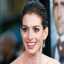

In [69]:
image

In [70]:
image = image.convert('L')

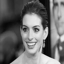

In [71]:
image

In [72]:
image_array = np.array(image).flatten()

In [73]:
image_array.shape

(4096,)

In [77]:
scaled_array = scaler.transform(image_array.reshape(1, -1))

In [78]:
 model.predict(scaled_array)

array([1])

# save a model

In [79]:
import pickle

In [81]:
pickle.dump(model, open('model.pkl','wb'))

In [82]:
pickle.dump(scaler, open('scaler.pkl', 'wb'))